In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from scipy.stats import kurtosis

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',100)

In [20]:
df=pd.read_csv("C:\\Users\\deepa\\OneDrive\\Documents\\amex\\amex_r1\\data\\dataset.csv")

feature_map=pd.read_csv("C:\\Users\\deepa\\OneDrive\\Documents\\amex\\amex_r1\\data\\features.csv")

In [6]:
print(df.shape)

df.head()

(500000, 24)


,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23
0,0,0.000000,0,1,98615.44,5620.938246,NaN,NaN,NaN,NaN,NaN,0.036093,4.0,0.0,0.0,0.0,49.280210,1960.0,1900.0,2.0,1.0,0.0,2.0,NaN
1,1,0.000000,0,0,21241.06,10196.878460,13865.4026,425.04840,27.9986,0.000,494.8428,0.000000,58.0,3.0,196.0,5.0,63.759364,34300.0,34650.0,3.0,2.0,163620.0,3.0,NaN
2,2,1224.690475,0,1,NaN,16.160000,NaN,NaN,NaN,NaN,NaN,0.182310,22.0,0.0,0.0,0.0,19.646836,NaN,NaN,1.0,1.0,NaN,9.0,NaN
3,3,0.000000,1,0,NaN,1635.316863,3231.1968,-269.15308,0.0000,0.000,48.5520,0.000040,NaN,0.0,0.0,0.0,9.143074,12348.0,12474.0,2.0,1.0,NaN,5.0,NaN
4,4,3824.366700,0,0,7140.87,5007.271790,4064.2152,16079.35060,377.9055,556.974,5354.3280,0.000253,3.0,0.0,0.0,11.0,63.759364,3672.0,3528.0,3.0,1.0,68640.0,0.0,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 24 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      500000 non-null  int64  
 1   f1      500000 non-null  float64
 2   f2      500000 non-null  int64  
 3   f3      500000 non-null  int64  
 4   f4      242772 non-null  float64
 5   f5      493660 non-null  float64
 6   f6      384302 non-null  float64
 7   f7      384302 non-null  float64
 8   f8      384302 non-null  float64
 9   f9      384302 non-null  float64
 10  f10     384302 non-null  float64
 11  f11     497490 non-null  float64
 12  f12     474995 non-null  float64
 13  f13     486284 non-null  float64
 14  f14     486284 non-null  float64
 15  f15     486284 non-null  float64
 16  f16     486284 non-null  float64
 17  f17     207746 non-null  float64
 18  f18     190556 non-null  float64
 19  f19     499978 non-null  float64
 20  f20     499899 non-null  float64
 21  f21     24

In [8]:
missing=pd.DataFrame()

missing["Missing_Count"]=df.isna().sum()

missing["Missing_%"]=100*missing["Missing_Count"]/len(df)

missing=missing.sort_values("Missing_%",ascending=False)

missing

,Missing_Count,Missing_%
f23,438965,87.7930
f18,309444,61.8888
f17,292254,58.4508
f4,257228,51.4456
f21,257228,51.4456
f6,115698,23.1396
f7,115698,23.1396
f8,115698,23.1396
f10,115698,23.1396
f9,115698,23.1396


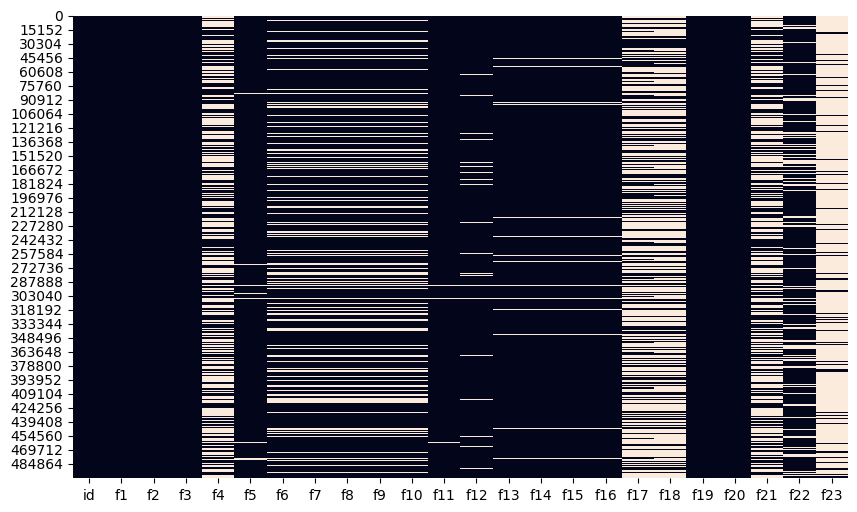

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isna(),cbar=False)

plt.show()

In [10]:
zero=pd.DataFrame()

zero["Zero_Count"]=(df==0).sum()

zero["Zero_%"]=100*zero["Zero_Count"]/len(df)

zero.sort_values("Zero_%",ascending=False)

,Zero_Count,Zero_%
f3,445696,89.1392
f2,413026,82.6052
f13,355020,71.0040
f14,326158,65.2316
f1,265977,53.1954
f11,165019,33.0038
f15,158946,31.7892
f9,140376,28.0752
f8,120073,24.0146
f21,103992,20.7984


In [11]:
stats=pd.DataFrame()

stats["Mean"]=df.mean(numeric_only=True)

stats["Median"]=df.median(numeric_only=True)

stats["Std"]=df.std(numeric_only=True)

stats["Min"]=df.min(numeric_only=True)

stats["Max"]=df.max(numeric_only=True)

stats["Skewness"]=df.apply(lambda x:skew(x.dropna()))

stats["Kurtosis"]=df.apply(lambda x:kurtosis(x.dropna()))

stats

,Mean,Median,Std,Min,Max,Skewness,Kurtosis
id,249999.500000,249999.500000,144337.711635,0.000000,499999.000000,8.717697e-17,-1.200000
f1,2467.312088,0.000000,4801.261745,0.000000,17967.726330,2.229189e+00,3.881001
f2,0.173948,0.000000,0.379065,0.000000,1.000000,1.720297e+00,0.959422
f3,0.108608,0.000000,0.311147,0.000000,1.000000,2.515803e+00,4.329266
f4,126607.131109,50705.190000,183366.588497,2.000000,697899.350000,1.971204e+00,3.015321
f5,3464.813312,2165.850798,3710.776424,0.000000,13596.279900,1.371606e+00,1.036655
f6,10032.050115,4022.766000,13981.489112,0.000000,52198.432000,1.825398e+00,2.440441
f7,30821.546800,14396.270950,39491.042972,-274.646000,146700.554000,1.692005e+00,1.987437
f8,1522.992929,303.993300,2521.700018,0.000000,9419.874000,2.025808e+00,3.130967
f9,1651.736560,264.746000,2869.234123,0.000000,10828.994000,2.127081e+00,3.547388


In [12]:
percentiles=df.describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99]).T

percentiles

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
id,500000.0,249999.500000,144337.711635,0.000000,4999.990000,24999.950000,49999.900000,124999.750000,249999.500000,374999.250000,449999.100000,474999.050000,494999.010000,499999.000000
f1,500000.0,2467.312088,4801.261745,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2436.194862,9496.962158,17249.017280,17967.726330,17967.726330
f2,500000.0,0.173948,0.379065,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
f3,500000.0,0.108608,0.311147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
f4,242772.0,126607.131109,183366.588497,2.000000,2.000000,2.080000,756.481000,8097.067500,50705.190000,150490.920000,395594.868000,669983.376000,697899.350000,697899.350000
f5,493660.0,3464.813312,3710.776424,0.000000,0.000000,0.000000,54.585756,668.571423,2165.850798,4911.806492,9336.884852,13052.428700,13596.279900,13596.279900
f6,384302.0,10032.050115,13981.489112,0.000000,0.000000,0.000000,0.000000,636.826300,4022.766000,12870.158300,31367.622630,50110.494720,52198.432000,52198.432000
f7,384302.0,30821.546800,39491.042972,-274.646000,-274.646000,-260.913700,407.885300,3337.599825,14396.270950,41278.605275,91944.576960,140832.531800,146700.554000,146700.554000
f8,384302.0,1522.992929,2521.700018,0.000000,0.000000,0.000000,0.000000,0.000000,303.993300,1777.084625,5288.003760,9043.079040,9419.874000,9419.874000
f9,384302.0,1651.736560,2869.234123,0.000000,0.000000,0.000000,0.000000,0.000000,264.746000,1809.549225,5805.632730,10395.834240,10828.994000,10828.994000


In [13]:
unique=pd.DataFrame()

unique["Unique"]=df.nunique()

unique.sort_values("Unique")

,Unique
f3,2
f2,2
f20,2
f23,3
f13,4
f19,4
f15,12
f22,16
f12,117
f16,298


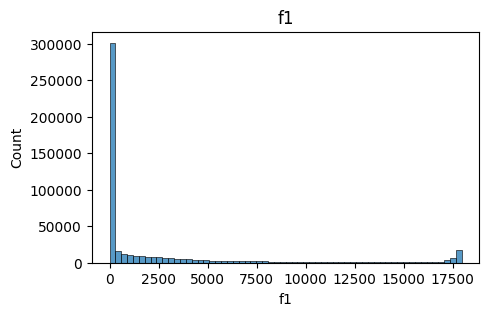

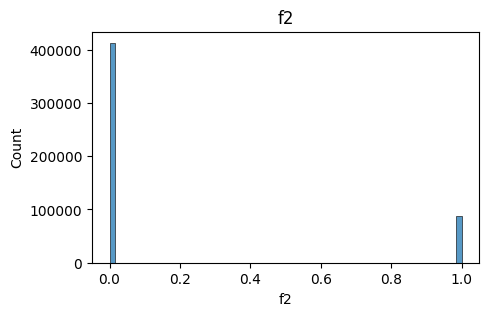

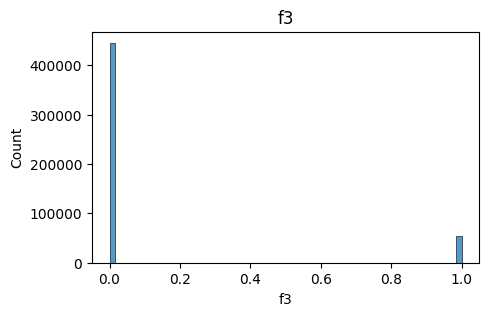

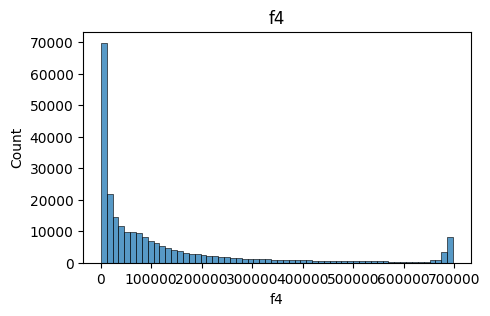

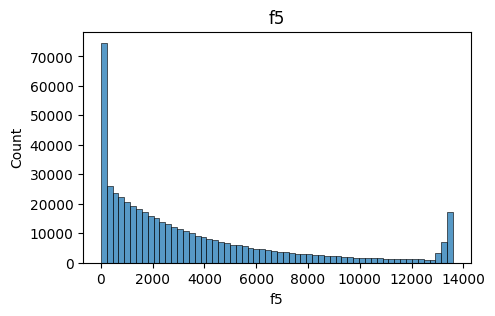

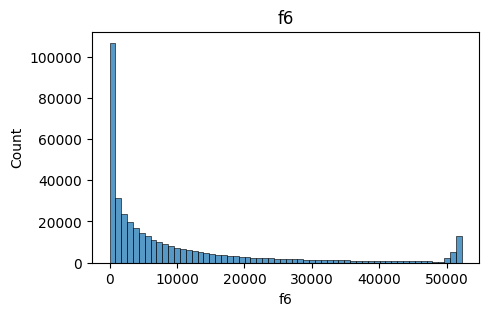

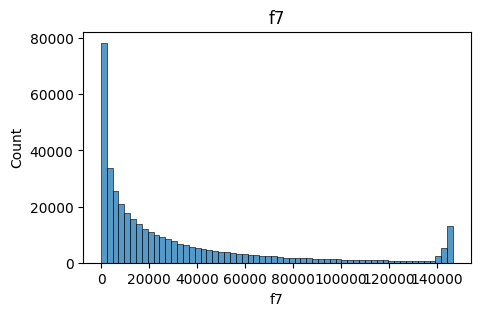

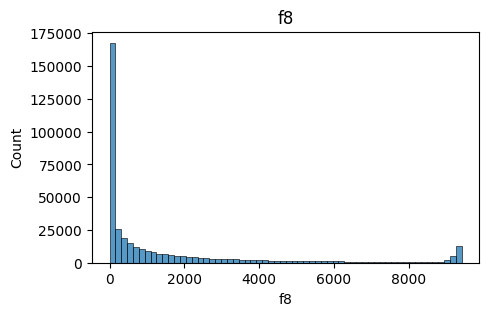

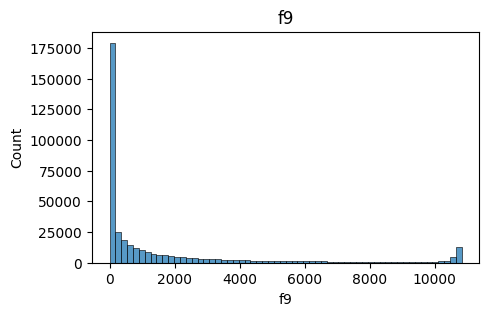

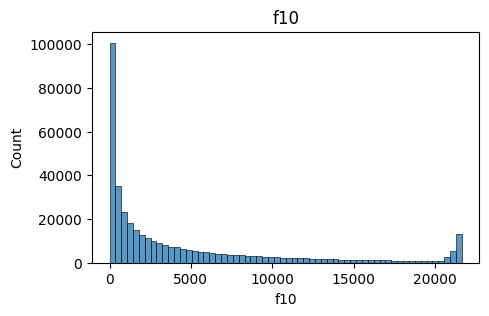

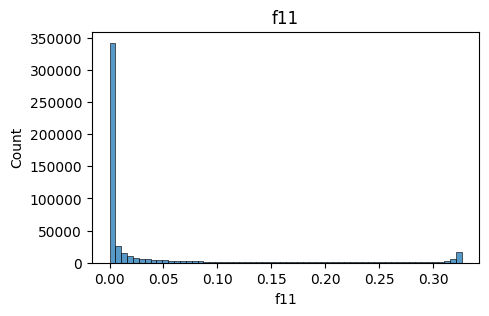

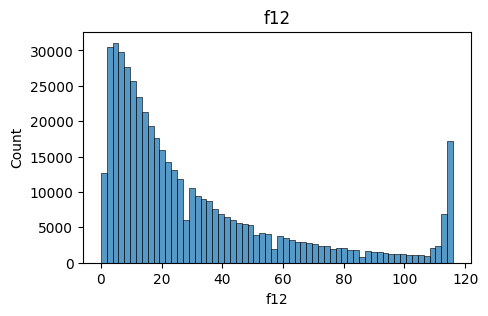

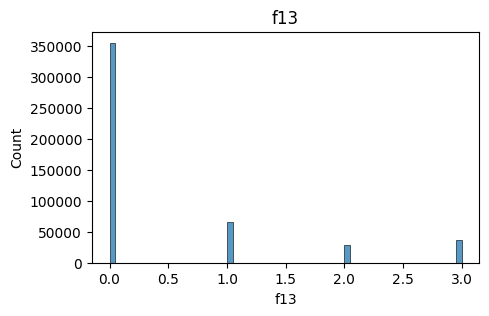

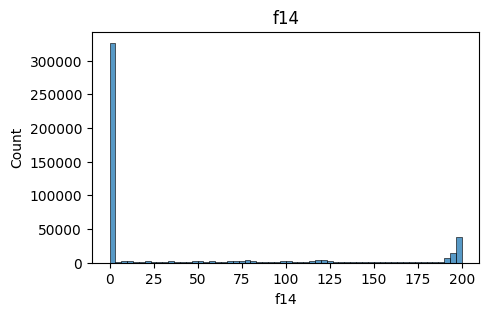

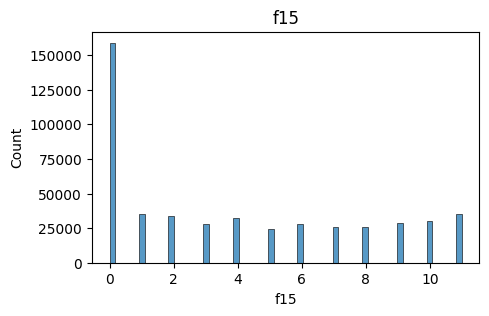

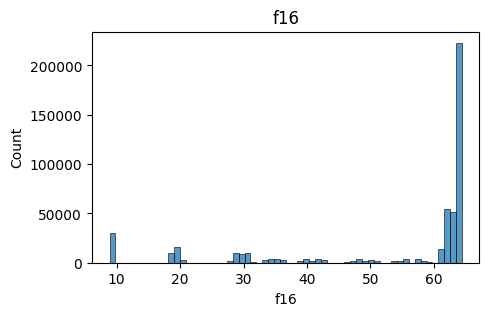

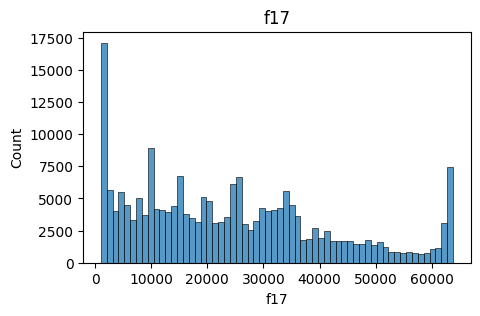

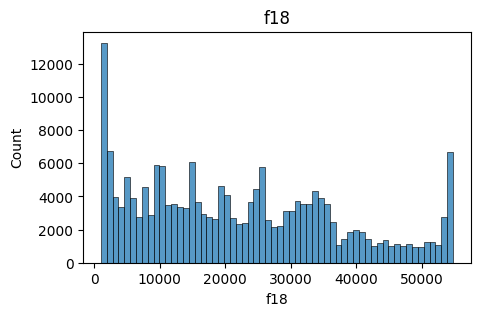

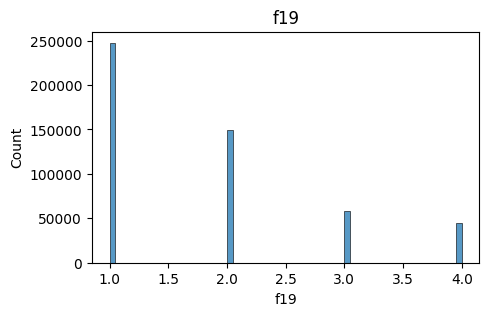

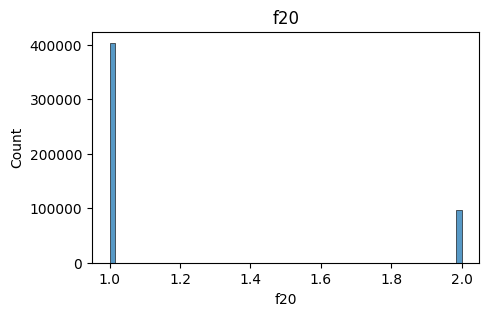

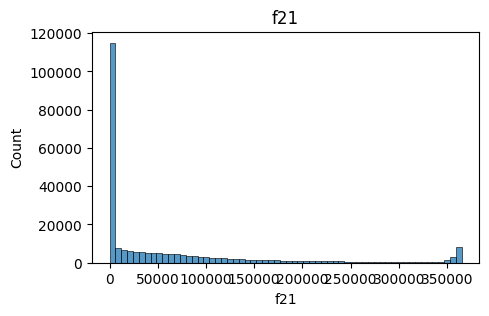

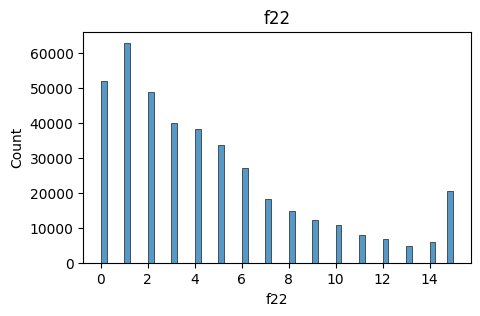

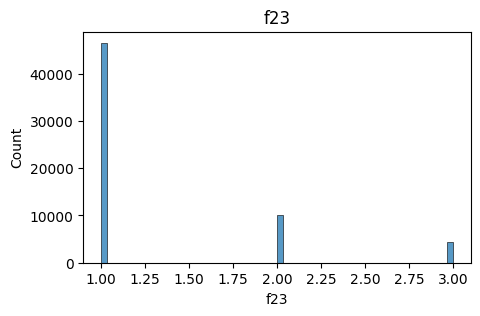

In [14]:
for col in df.columns[1:]:

    plt.figure(figsize=(5,3))

    sns.histplot(df[col],bins=60)

    plt.title(col)

    plt.show()

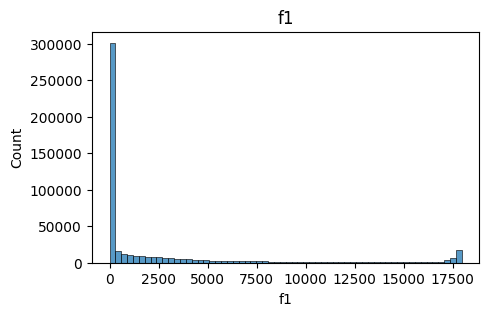

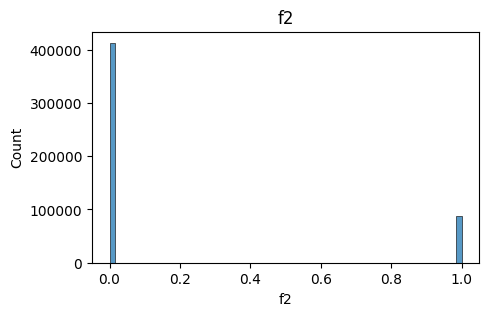

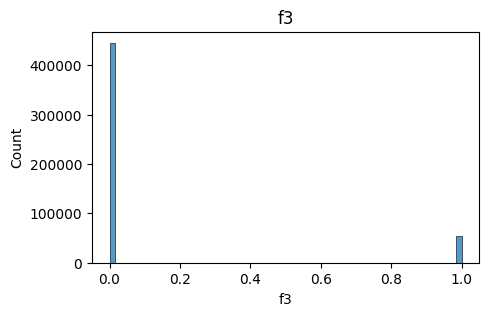

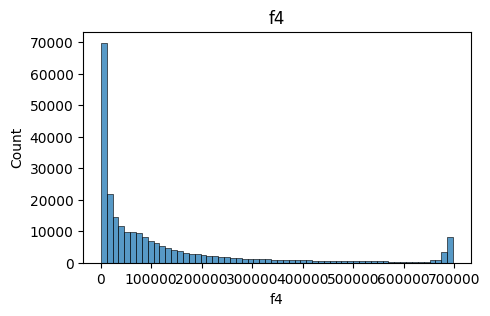

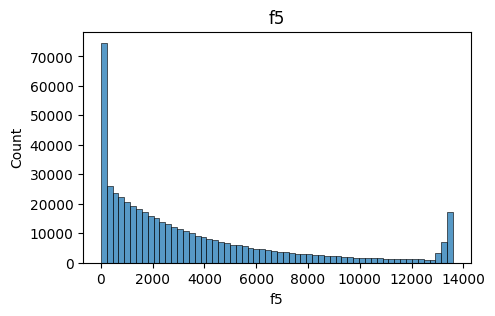

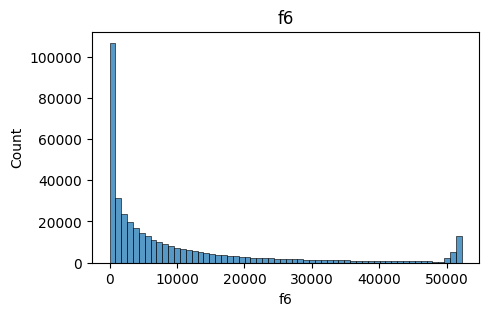

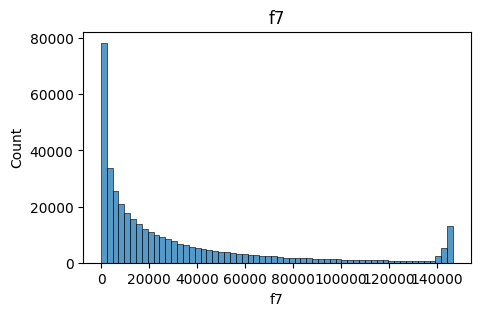

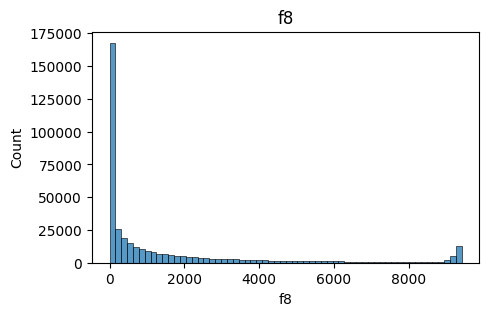

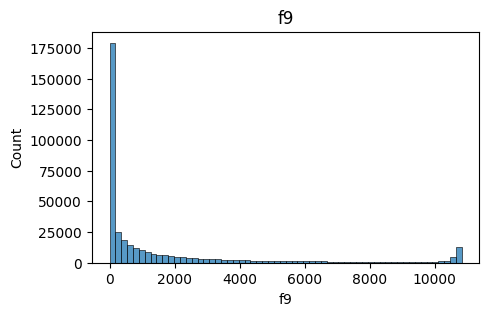

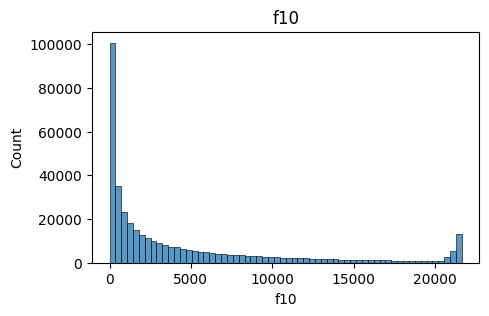

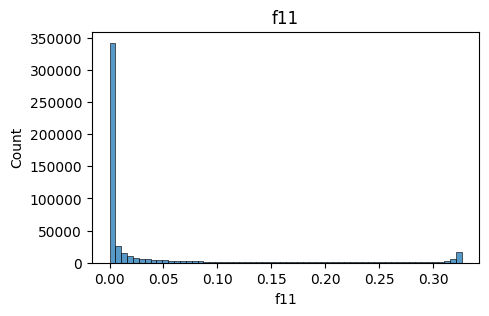

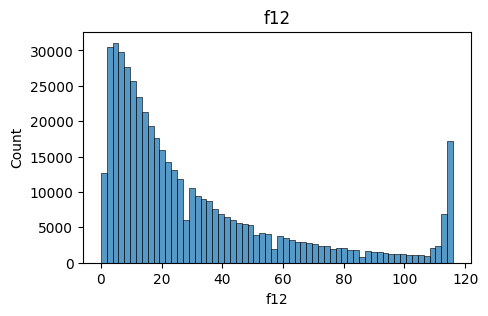

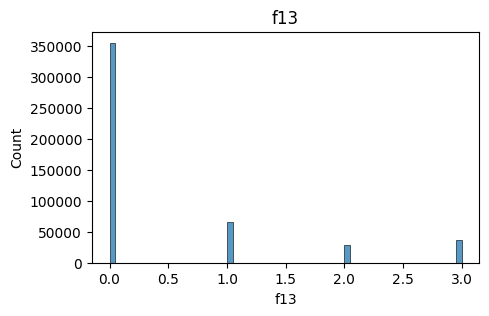

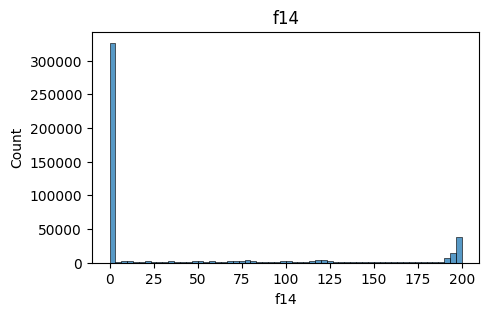

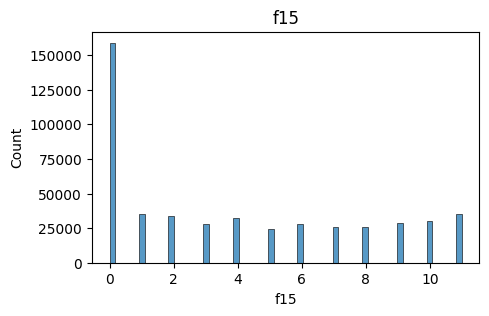

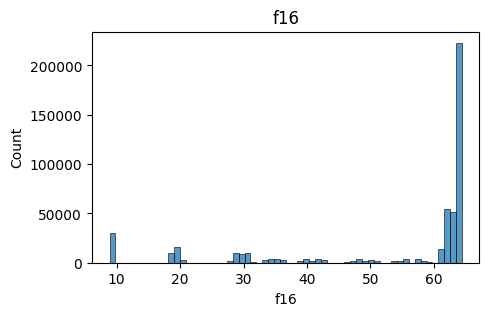

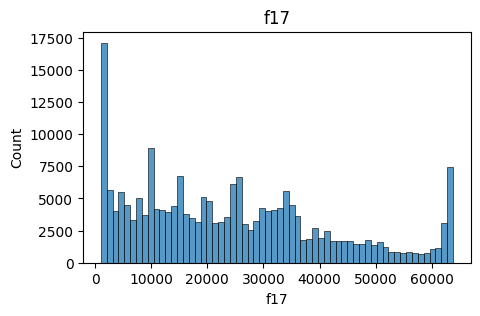

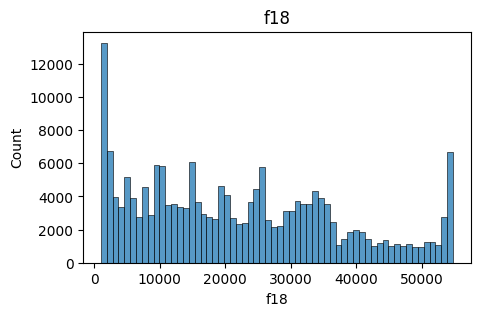

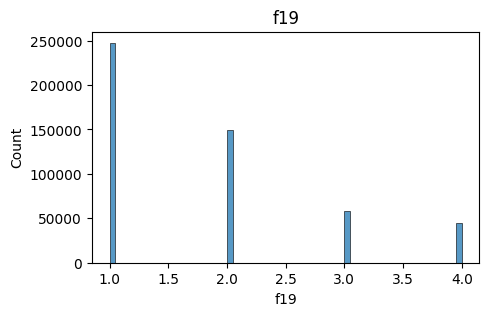

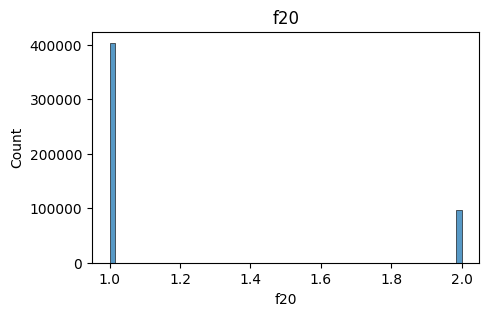

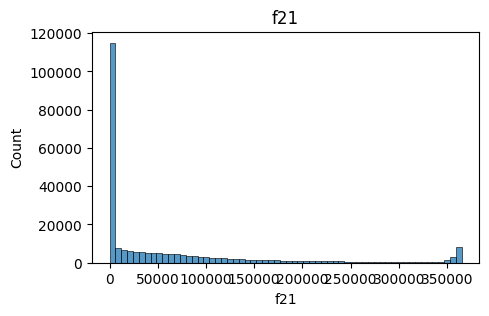

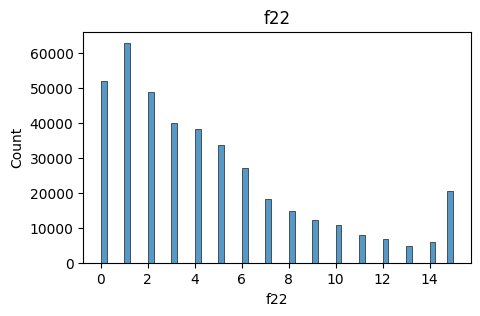

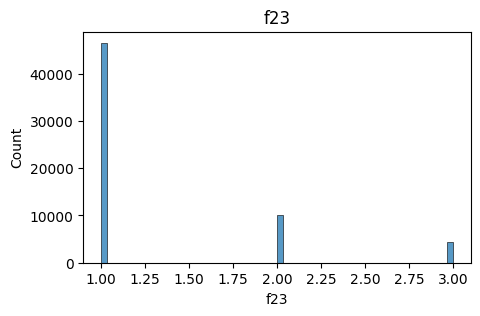

In [15]:
for col in df.columns[1:]:

    plt.figure(figsize=(5,3))

    sns.histplot(df[col],bins=60)

    plt.title(col)

    plt.show()

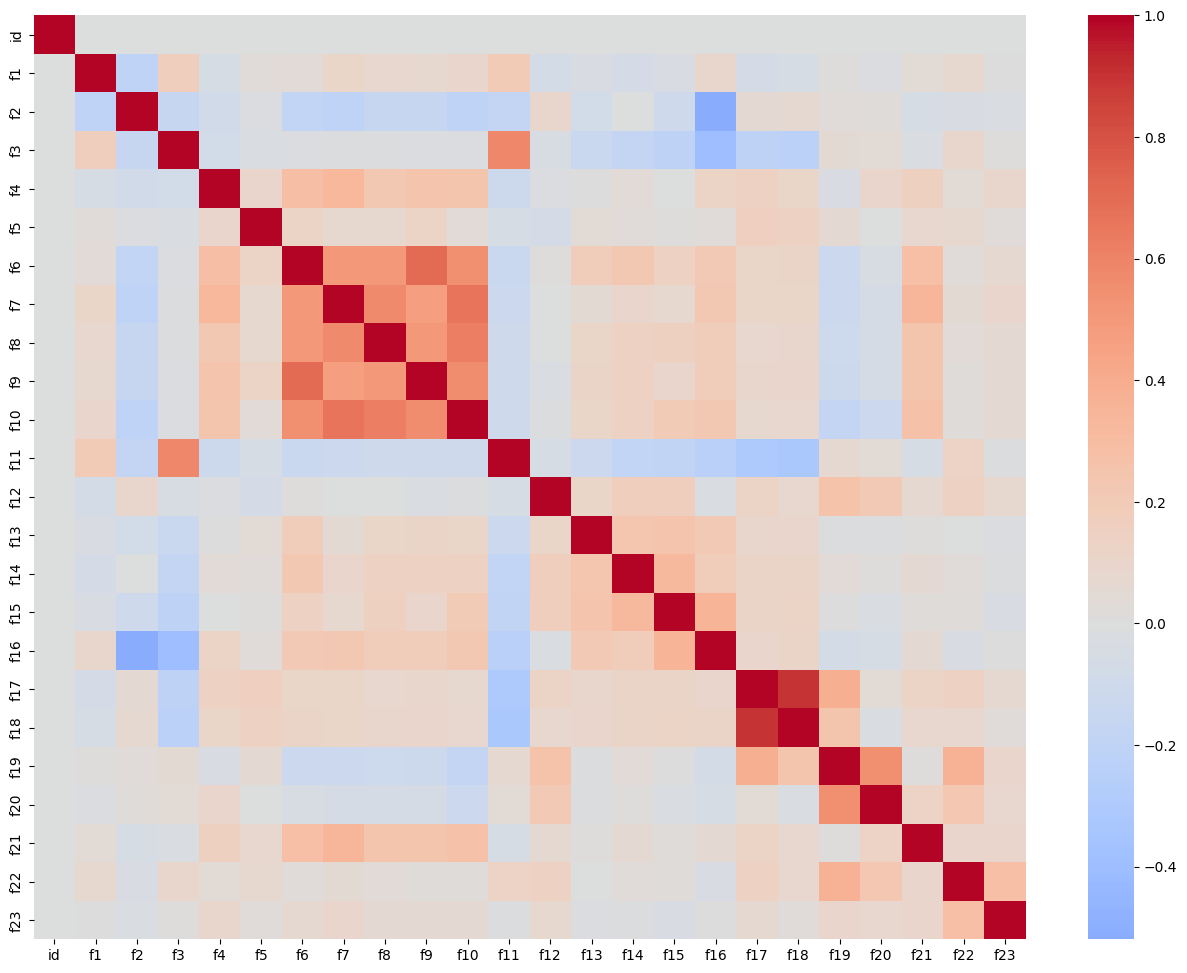

In [16]:
corr=df.corr(numeric_only=True)

plt.figure(figsize=(16,12))

sns.heatmap(corr,
            cmap="coolwarm",
            center=0)

plt.show()

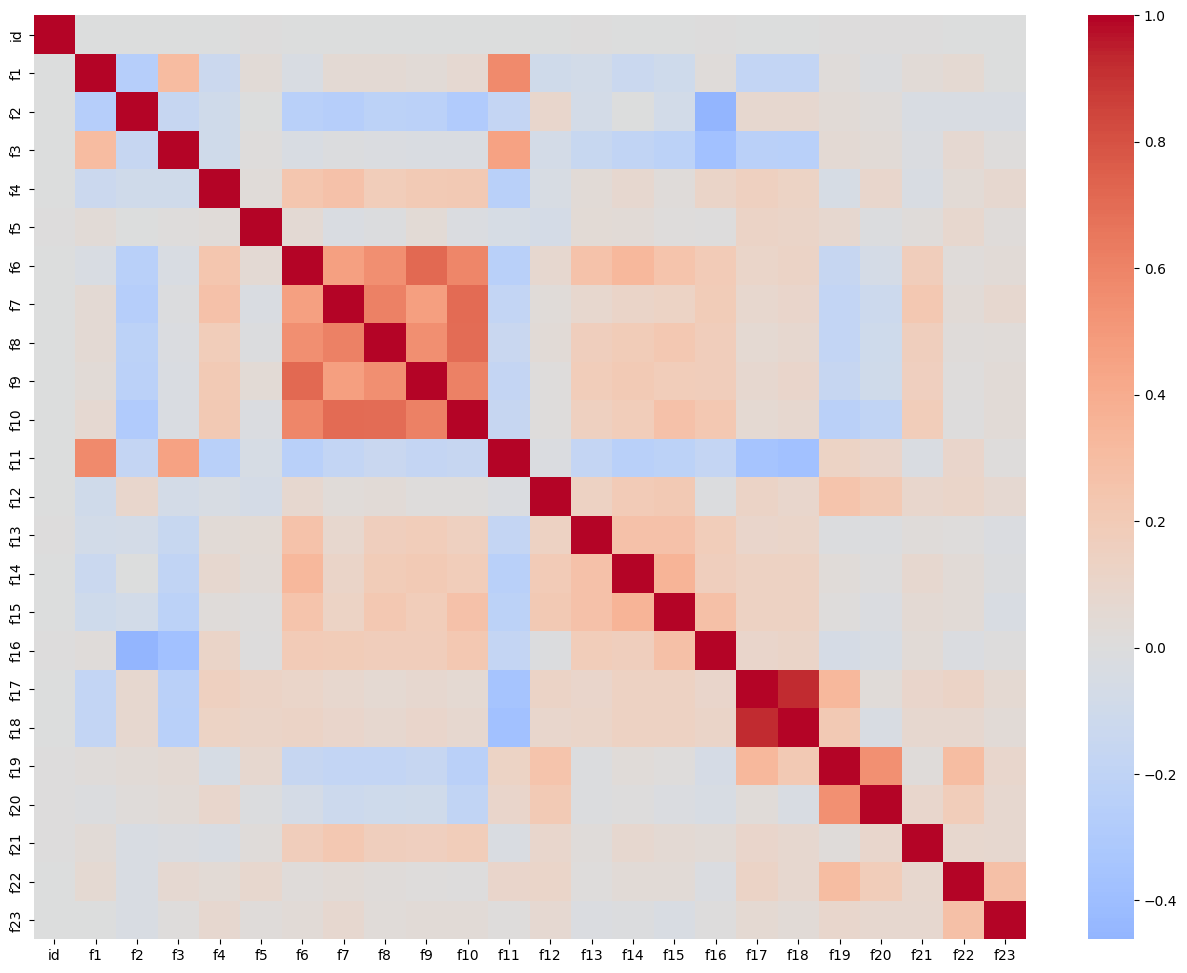

In [17]:
corr=df.corr(method="spearman",numeric_only=True)

plt.figure(figsize=(16,12))

sns.heatmap(corr,
            cmap="coolwarm",
            center=0)

plt.show()

In [18]:
outliers=[]

for col in df.columns[1:]:

    Q1=df[col].quantile(.25)

    Q3=df[col].quantile(.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR

    count=((df[col]<lower)|(df[col]>upper)).sum()

    outliers.append([col,count])

outliers=pd.DataFrame(outliers,
                      columns=["Feature","Outlier_Count"])

outliers

,Feature,Outlier_Count
0,f1,70258
1,f2,86974
2,f3,54304
3,f4,26549
4,f5,35353
5,f6,38651
6,f7,35045
7,f8,46039
8,f9,48819
9,f10,34641


In [19]:
feature_map

,Feature Name,Feature Description
0,id,id
1,f1,Average Revolve Balance in last 12m
2,f2,Cancellation Calls in last 12m
3,f3,Cancellation Calls due to Collection
4,f4,Rewards Points Balance
5,f5,Total Spend in last 12m
6,f6,Airlines Spend in 12m
7,f7,Other Spend in 12m
8,f8,Entertainment Spend in 12m
9,f9,Lodging Spend in 12m


| Feature | Revenue | Cost | Risk | Engagement | Relationship |
| ------- | ------- | ---- | ---- | ---------- | ------------ |
| f1      | YES     |      |      |            |              |
| f5      | YES     |      |      |            |              |
| f21     |         | YES  |      |            |              |
| f11     |         |      | YES  |            |              |
| f12     |         |      |      | YES        |              |


1. Structural Missingness (Very Important)

These are not random missing values.

Feature	Missing	Interpretation
f23	87.8%	No email clicks
f18	61.9%	Likely no consumer lend line
f17	58.5%	Likely no lend line
f4	51.4%	No rewards balance
f21	51.4%	No rewards redeemed
f6–f10	23.1%	No category spend recorded

Decision:

Do not use median imputation.
Create missing indicators.
Fill structural NaNs with 0 only after creating indicators.